# ClinicAI Disease Prediction Training
This notebook trains models for Diabetes and Kidney disease using real datasets.

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier

# --- CONFIG --- 
DIABETES_PATH = r'c:/Users/hpc/Downloads/ClinicApp-main/ClinicAI/notebooks/diabetes_prediction_dataset.csv'
KIDNEY_PATH   = r'c:/Users/hpc/Downloads/ClinicApp-main/ClinicAI/notebooks/kidney_disease.csv'

def to_binary(v):
    if pd.isna(v): return np.nan
    s = str(v).strip().lower()
    if s in {'0', 'no', 'negative', 'normal', 'false', 'notckd'}: return 0
    if s in {'1', 'yes', 'positive', 'abnormal', 'true', 'ckd'}:  return 1
    return 0 if 'not' in s else 1

def build_preprocessor(X):
    cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
    num_cols = [c for c in X.columns if c not in cat_cols]
    num_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
    cat_pipe = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))])
    return ColumnTransformer([('num', num_pipe, num_cols), ('cat', cat_pipe, cat_cols)])

--- Training Diabetes Model ---


C:\Users\hpc\AppData\Local\Temp\ipykernel_1948\2108719184.py:26: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()


Diabetes Accuracy: 0.9712
              precision    recall  f1-score   support

           0       0.97      1.00      0.98     18300
           1       0.96      0.69      0.80      1700

    accuracy                           0.97     20000
   macro avg       0.96      0.84      0.89     20000
weighted avg       0.97      0.97      0.97     20000



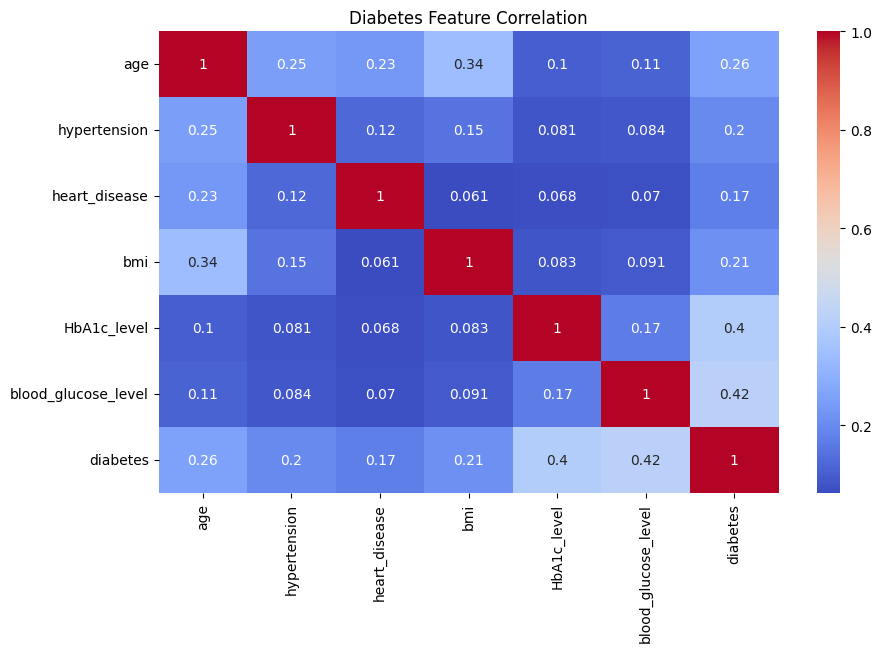

In [2]:
print('--- Training Diabetes Model ---')
df_d = pd.read_csv(DIABETES_PATH)
df_d['smoking_history'] = df_d['smoking_history'].replace('No Info', np.nan)
feat_d = ['HbA1c_level', 'blood_glucose_level', 'age', 'bmi', 'smoking_history', 'hypertension', 'gender', 'heart_disease']
X_d = df_d[feat_d]
y_d = df_d['diabetes'].apply(to_binary).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X_d, y_d, test_size=0.2, random_state=42, stratify=y_d)
model_d = Pipeline([('preprocessor', build_preprocessor(X_d)), ('classifier', XGBClassifier(random_state=42))])
model_d.fit(X_train, y_train)

print(f'Diabetes Accuracy: {accuracy_score(y_test, model_d.predict(X_test)):.4f}')
print(classification_report(y_test, model_d.predict(X_test)))

plt.figure(figsize=(10,6))
sns.heatmap(df_d.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.title('Diabetes Feature Correlation')
plt.show()


--- Training Kidney Model ---
Kidney Accuracy: 0.9875
              precision    recall  f1-score   support

           0       0.97      1.00      0.98        30
           1       1.00      0.98      0.99        50

    accuracy                           0.99        80
   macro avg       0.98      0.99      0.99        80
weighted avg       0.99      0.99      0.99        80



C:\Users\hpc\AppData\Local\Temp\ipykernel_1948\2108719184.py:26: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()


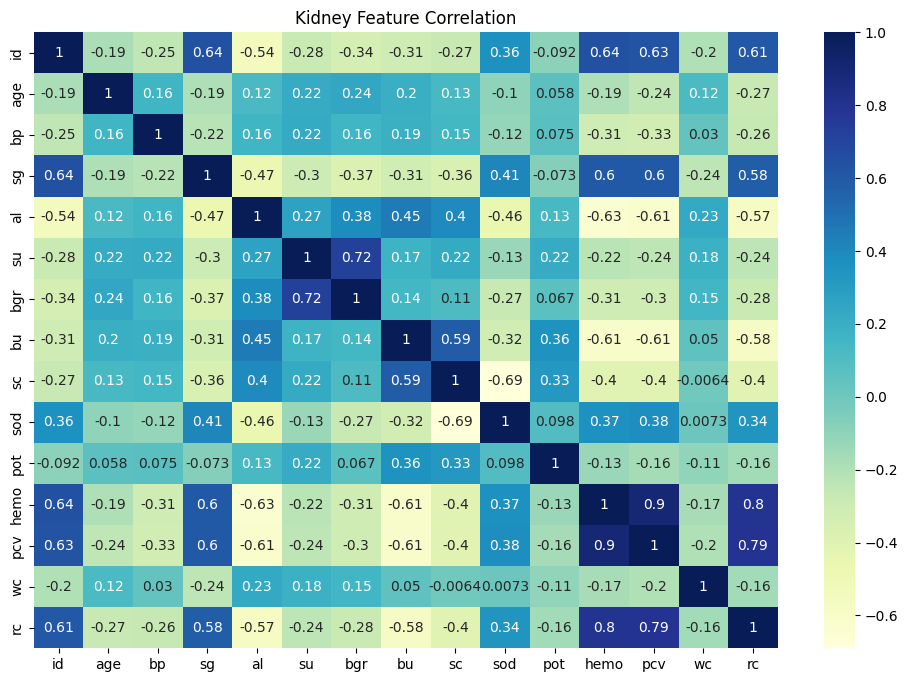

In [3]:
print('\n--- Training Kidney Model ---')
df_k = pd.read_csv(KIDNEY_PATH)
df_k.columns = [c.strip() for c in df_k.columns]
df_k['classification'] = df_k['classification'].replace('ckd\t', 'ckd')
for col in ['pcv', 'wc', 'rc']: df_k[col] = pd.to_numeric(df_k[col], errors='coerce')

feat_k = ['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']
X_k = df_k[feat_k]
y_k = df_k['classification'].apply(to_binary).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X_k, y_k, test_size=0.2, random_state=42, stratify=y_k)
model_k = Pipeline([('preprocessor', build_preprocessor(X_k)), ('classifier', XGBClassifier(random_state=42))])
model_k.fit(X_train, y_train)

print(f'Kidney Accuracy: {accuracy_score(y_test, model_k.predict(X_test)):.4f}')
print(classification_report(y_test, model_k.predict(X_test)))

plt.figure(figsize=(12,8))
sns.heatmap(df_k.select_dtypes(include=[np.number]).corr(), annot=True, cmap='YlGnBu')
plt.title('Kidney Feature Correlation')
plt.show()